In [3]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import re
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from scipy.stats import uniform
import jax

import time
import emcee

Optional mpi4py package is not installed.  MPI support is not available.


In [4]:
# path to the folder with the data
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9] # we are only analysing pulsar #9

In [5]:
print('tipo oggetto :', type(psr))
print('nome         :', psr.name)
print('N_TOA        :', len(psr.toas))
print('baseline (yr):', (psr.toas.max() - psr.toas.min()) / (86400 * 365.25))
print('prime 3 TOA  :', psr.toas[:3])
print('prime 3 res  :', psr.residuals[:3])
print('prime 3 err  :', psr.toaerrs[:3])
print('prime 3 freq :', psr.freqs[:3])
print('shape M      :', psr.Mmat.shape)
print('noisedict (primi 10):', list(psr.noisedict.keys())[:10])

tipo oggetto : <class 'discovery_new.pulsar.Pulsar'>
nome         : J1640+2224
N_TOA        : 6777
baseline (yr): 12.161390639760242
prime 3 TOA  : [4.80842241e+09 4.80842241e+09 4.80914896e+09]
prime 3 res  : [ 6.75606258e-06  3.70683122e-06 -8.42886318e-07]
prime 3 err  : [1.0817e-05 1.8530e-06 2.8700e-06]
prime 3 freq : [1418.16092262 1620.26420971 1618.54894122]
shape M      : (6777, 39)
noisedict (primi 10): ['J1640+2224_DE601.150_efac', 'J1640+2224_DE601.150_log10_ecorr', 'J1640+2224_DE601.150_log10_tnequad', 'J1640+2224_DE602.150_efac', 'J1640+2224_DE602.150_log10_ecorr', 'J1640+2224_DE602.150_log10_tnequad', 'J1640+2224_DE603.150_efac', 'J1640+2224_DE603.150_log10_ecorr', 'J1640+2224_DE603.150_log10_tnequad', 'J1640+2224_DE604.150_efac']


In [6]:
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [7]:
logL = ds.PulsarLikelihood(model).logL

In [8]:
logL.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [9]:
# annoying function needed because the function logL want a dictionary as input, but our sampler wants a likelihood with an array as input
# so we have to switch from one to another :(
def params_dict_from_array(x):
    # ensure x is a plain numpy array before slicing
    x = np.asarray(x)
    return dict(zip(logL.params, x))

In [10]:
##### Cell for the prior distributions ###################################################################################

# dictionary with minimum and maximum value of the prior distribution
my_priordict = {}
my_priordict["(.*_)?sv_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?sv_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_log10_A.*"] = [-10, 1]
my_priordict["(.*_)?sw_gamma.*"] = [-5, 6]
my_priordict["(.*_)?dm_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?dm_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?red_noise_gamma.*"] = [0, 7]
my_priordict["(.*_)?red_noise_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_n_earth.*"] = [0, 30]


def build_priors(param_names, priordict):
    """
    Build a {param_name: scipy dist} dict with uniform prior distributions in the range
    """
    priors = {}
    unmatched = []
    for name in param_names:
        matched = False
        for pattern, (lo, hi) in priordict.items():
            if re.fullmatch(pattern, name):
                priors[name] = uniform(loc=lo, scale=hi - lo) ## this is where the uniform distribution is defined
                matched = True
                break
        if not matched:
            unmatched.append(name)

    if unmatched:
        print(f"Warning: no prior found for {len(unmatched)} parameters, "
              f"falling back to standard normal:\n  {unmatched}")
    return priors

priors = build_priors(logL.params, my_priordict)
priors

def log_prior(x):
    """Compute log prior"""
    params = params_dict_from_array(x)
    
    logp = 0.0
    for name, value in params.items():
        if name in priors:
            logp += priors[name].logpdf(value)
        else:
            # Default: standard normal prior
            if isinstance(value, np.ndarray):
                logp += -0.5 * np.sum(value**2)
            else:
                logp += -0.5 * value**2
    
    return logp

def prior_draw():
    """Draw from prior and return as flat array"""
    x = []
    for name in logL.params:
        x.append(priors[name].rvs())
    return np.array(x)

x0 = prior_draw()
x0

array([  5.78345291, -16.33815814,   5.3003135 , -11.85785099,
         2.45563521, -11.2529783 ])

In [11]:
# let's try to compute the likleihood at a random point of the prior volume
#x0 = prior_draw()
params = params_dict_from_array(x0)
print(params)
print('Likelihood =', logL(params))

{'J1640+2224_dm_gp_gamma': np.float64(5.783452910377863), 'J1640+2224_dm_gp_log10_A': np.float64(-16.338158144134113), 'J1640+2224_red_noise_gamma': np.float64(5.300313497242962), 'J1640+2224_red_noise_log10_A': np.float64(-11.857850987031142), 'J1640+2224_sv_gp_gamma': np.float64(2.4556352060627704), 'J1640+2224_sv_gp_log10_A': np.float64(-11.25297830457105)}
Likelihood = 67415.10726803857


In [12]:
@jax.jit # compile the likelihood in jax to make it faster
def _jit_logL(params_array):
    params = dict(zip(logL.params, params_array))
    return logL(params)

_jit_logL(x0)

def log_likelihood(x): 
    """
    Likelihood function that is given to the samples, it uses the jitted (=faster) version of the likelihood
    """
    x = np.asarray(x, dtype=np.float64)
    result = _jit_logL(jnp.array(x))
    return float(np.array(result))  # always a plain Python float

In [13]:
# let's see how much time does one evaluation of the likelihood take
start = time.time()
logL(params)
print('Not jitted likelihood =', time.time() - start, 's')
start = time.time()
_jit_logL(x0)
print('Jitted likelihood =', time.time() - start, 's')   # it is faster right?

Not jitted likelihood = 0.00496983528137207 s
Jitted likelihood = 0.0005812644958496094 s


In [14]:
# let's define the sampler
sampler = ptmcmc(
    ndim=len(logL.params),                                        # how many parameters we have
    logl=log_likelihood,                                          # likelihood function 
    logp=log_prior,                                               # prior function
    cov=np.eye(len(logL.params)) * 0.001,                         # Small initial covariance
    outDir='./test/',                                              # output directory
    resume = True
)

In [15]:
# Run sampler
print("\nStarting sampling...")
sampler.sample(x0, Niter=1000000, thin=10)


Starting sampling...
Resuming run from chain file ./test//chain_1.txt
Resuming with 100001 samples from file representing 1000001 original samples
Adding DE jump with weight 20

Run Complete


In [16]:
# read the output chain that has shape (n_samples, n_parameters)
chain = np.loadtxt('./test/chain_1.txt')[:, :-4]
chain = chain[len(chain) // 4:] # remove first 25% from the chain
chain.shape

(75001, 6)

In [17]:
import os
print(os.path.exists('./J1640+2224/tm_wn_ecorrlofar_rn54_dm40_sv40/ptmcmc/pars.txt'))

True


In [18]:
pars = np.loadtxt('./J1640+2224/tm_wn_ecorrlofar_rn54_dm40_sv40/ptmcmc/pars.txt', dtype=str)
pars[-6:] 

array(['J1640+2224_cn_4.0_gamma', 'J1640+2224_cn_4.0_log10_A',
       'J1640+2224_dm_gamma', 'J1640+2224_dm_log10_A',
       'J1640+2224_red_noise_gamma', 'J1640+2224_red_noise_log10_A'],
      dtype='<U39')

In [19]:
chain_1 = np.loadtxt('./J1640+2224/tm_wn_ecorrlofar_rn54_dm40_sv40/ptmcmc/chain_1.txt')
print('shape:', chain_1.shape)
print(len(pars))

shape: (300001, 43)
39


In [20]:
chain_1[:, -6:]

array([[ 2.33647413e+00, -1.39764374e+01,  5.94986691e+04,
         5.95726623e+04,  0.00000000e+00,  1.00000000e+00],
       [ 2.33699254e+00, -1.62040684e+01,  5.95033700e+04,
         5.95773632e+04,  7.44000000e-01,  1.00000000e+00],
       [ 2.33822513e+00, -1.62065302e+01,  5.95079932e+04,
         5.95819864e+04,  7.44000000e-01,  1.00000000e+00],
       ...,
       [ 5.33268668e-02, -1.33372854e+01,  6.81850152e+04,
         6.82590084e+04,  1.85508000e-01,  1.00000000e+00],
       [ 5.33268668e-02, -1.33372854e+01,  6.81850320e+04,
         6.82590252e+04,  1.85508000e-01,  1.00000000e+00],
       [ 5.16516089e-02, -1.33375489e+01,  6.81848848e+04,
         6.82588780e+04,  1.85508000e-01,  1.00000000e+00]],
      shape=(300001, 6))

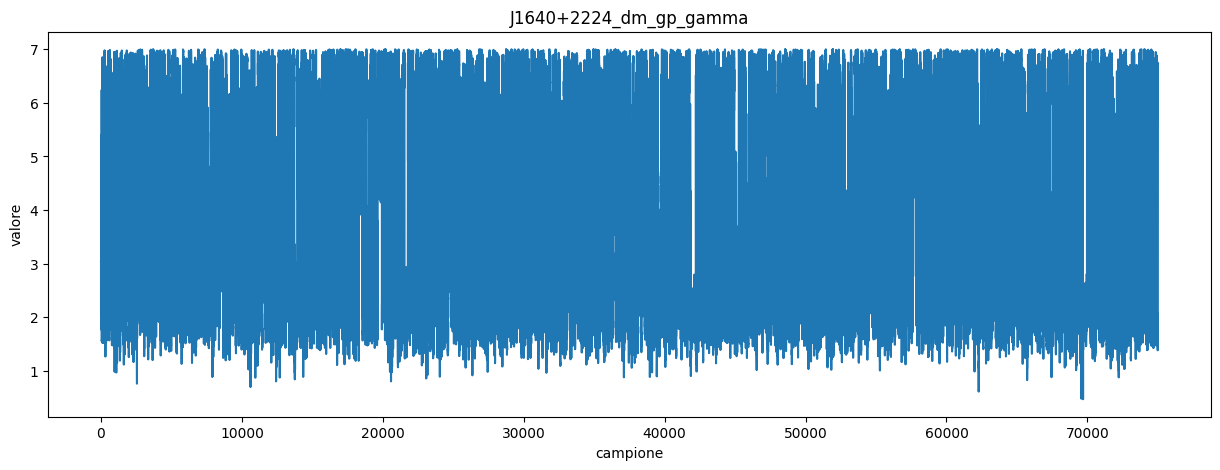

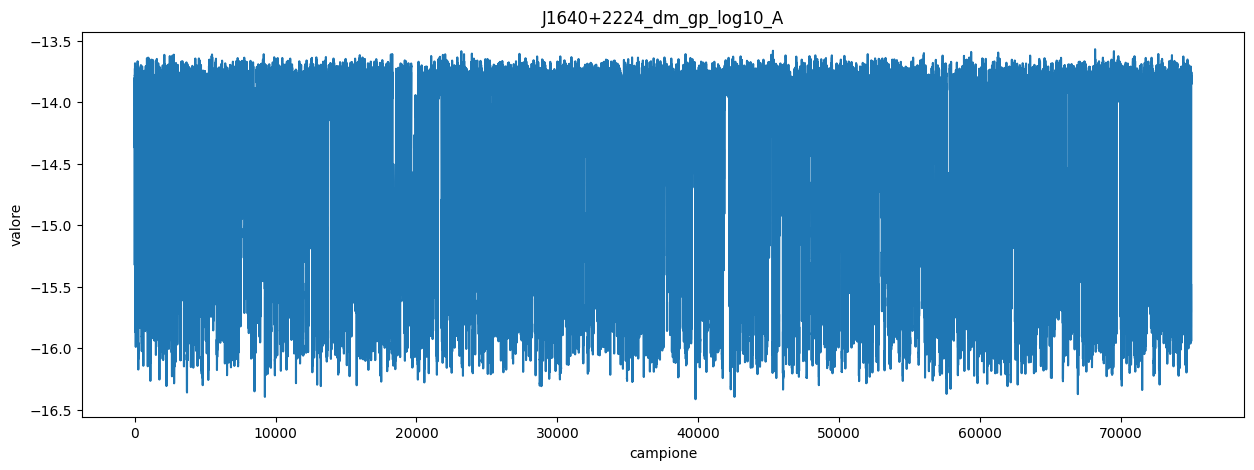

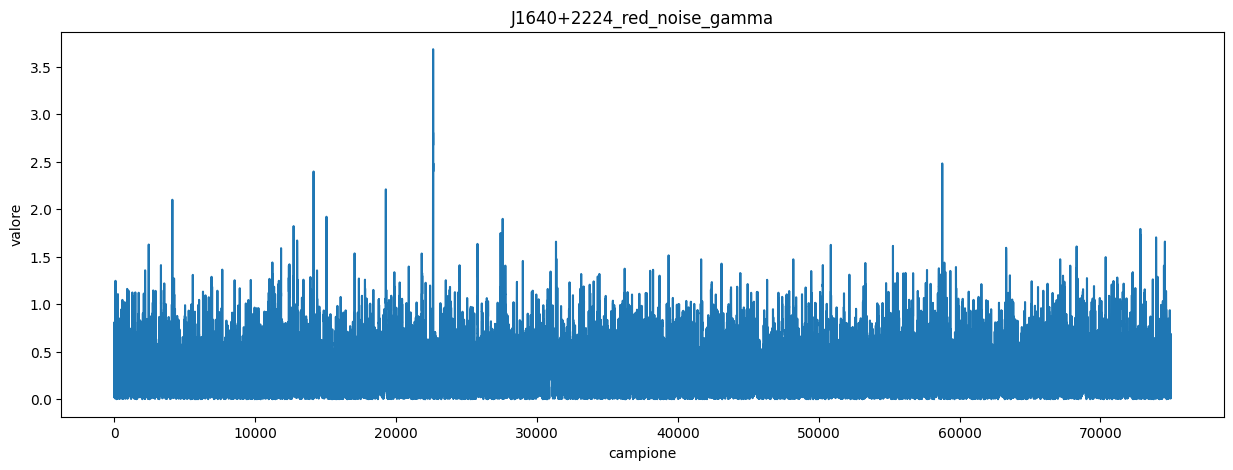

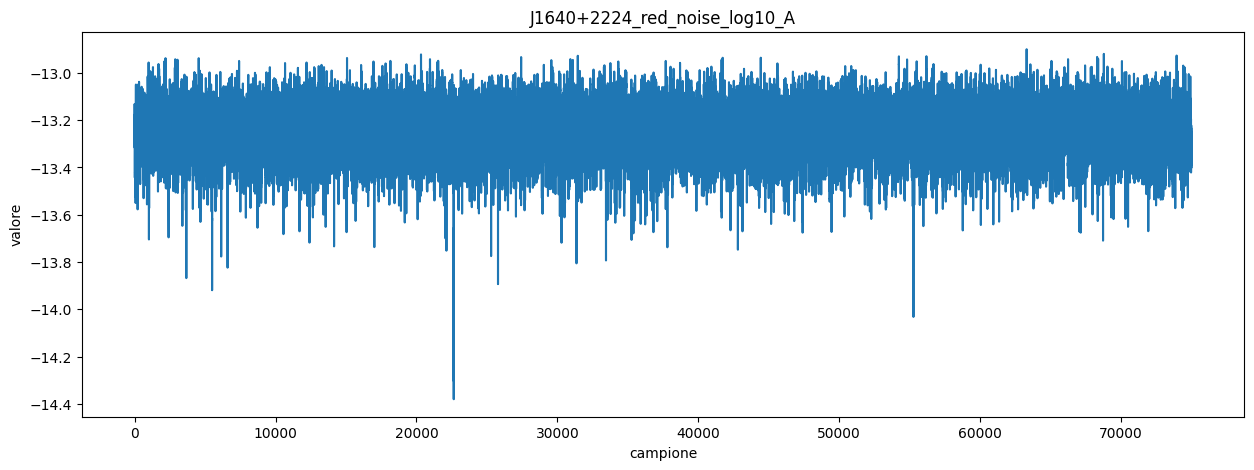

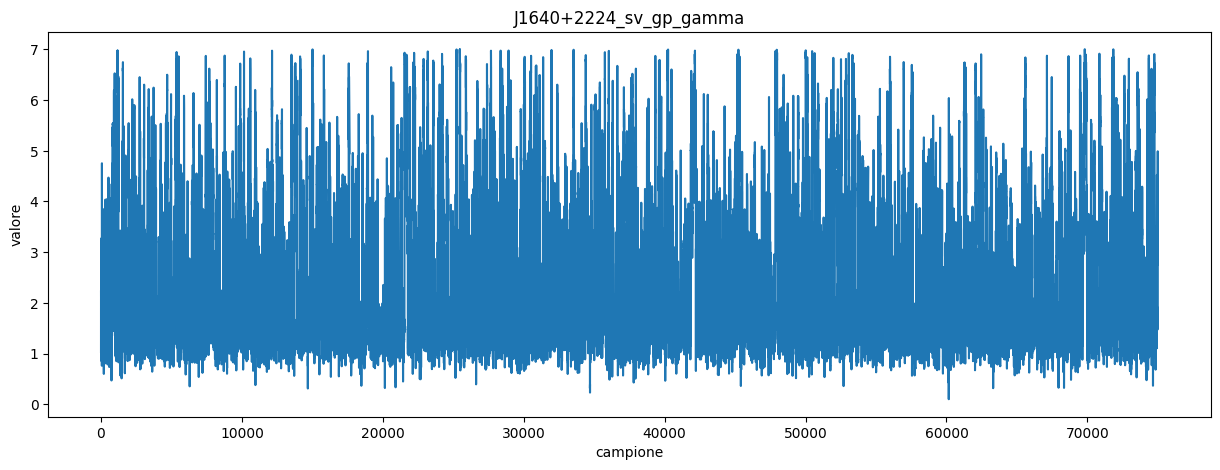

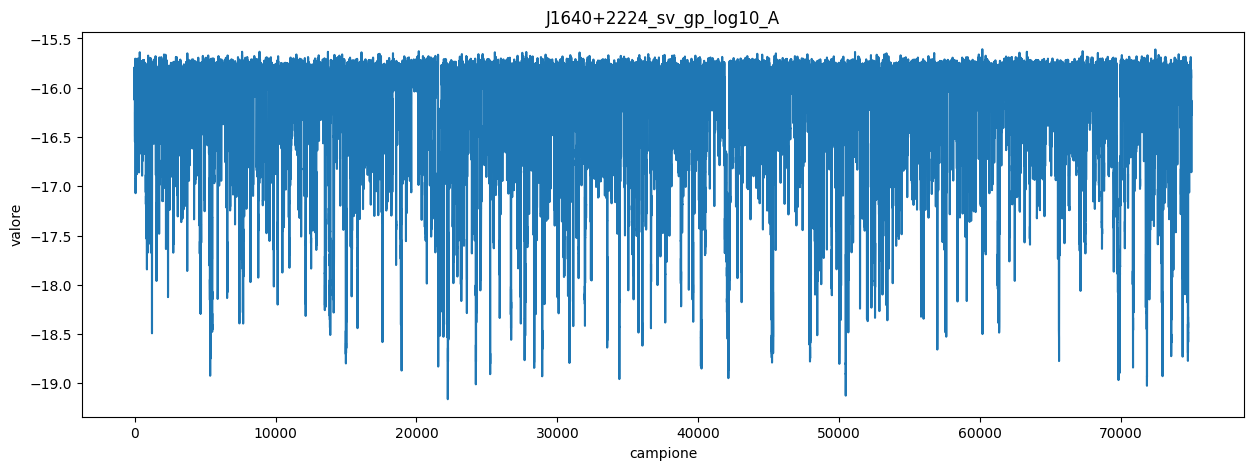

In [21]:
for i, ch in enumerate(chain.T):
    plt.figure(figsize=(15, 5))
    plt.plot(ch)
    plt.title(logL.params[i])
    plt.xlabel('campione')
    plt.ylabel('valore')
    plt.show()

In [22]:
import emcee
tau = emcee.autocorr.integrated_time(chain)
tau

array([35.91756038])

In [23]:
print('Effective length of the chain = ', len(chain[::int(tau[0])])) # this number should be at least > 1000, ideally around 10000

Effective length of the chain =  2143


In [141]:
#print('chain.shape:', chain.shape)

#tau = np.array([
 #   emcee.autocorr.integrated_time(chain[:, i], quiet=True)[0]
#    for i in range(chain.shape[1])
#])
#print('tau Discovery (6 valori):', tau)
#print('Effective length (Discovery) =', int(len(chain) / tau.max()))

In [24]:
tau = emcee.autocorr.integrated_time(chain, has_walkers=False, quiet=True)
print('tau (6 valori):', tau)

tau (6 valori): [39.3037739  39.37783775 15.53577259  7.69979909 55.50270977 65.72844062]


In [25]:
print('Effective length (Discovery) =', int(len(chain) / tau.max()))

Effective length (Discovery) = 1141


In [106]:
#import corner
#fig = corner.corner(chain[:], labels=logL.params, show_titles=True);
#corner.corner(chain[:], labels=logL.params, show_titles=True, fig=fig);

In [113]:
#import corner
#corner.corner(chain[::int(tau[0])], labels=logL.params, show_titles=True);

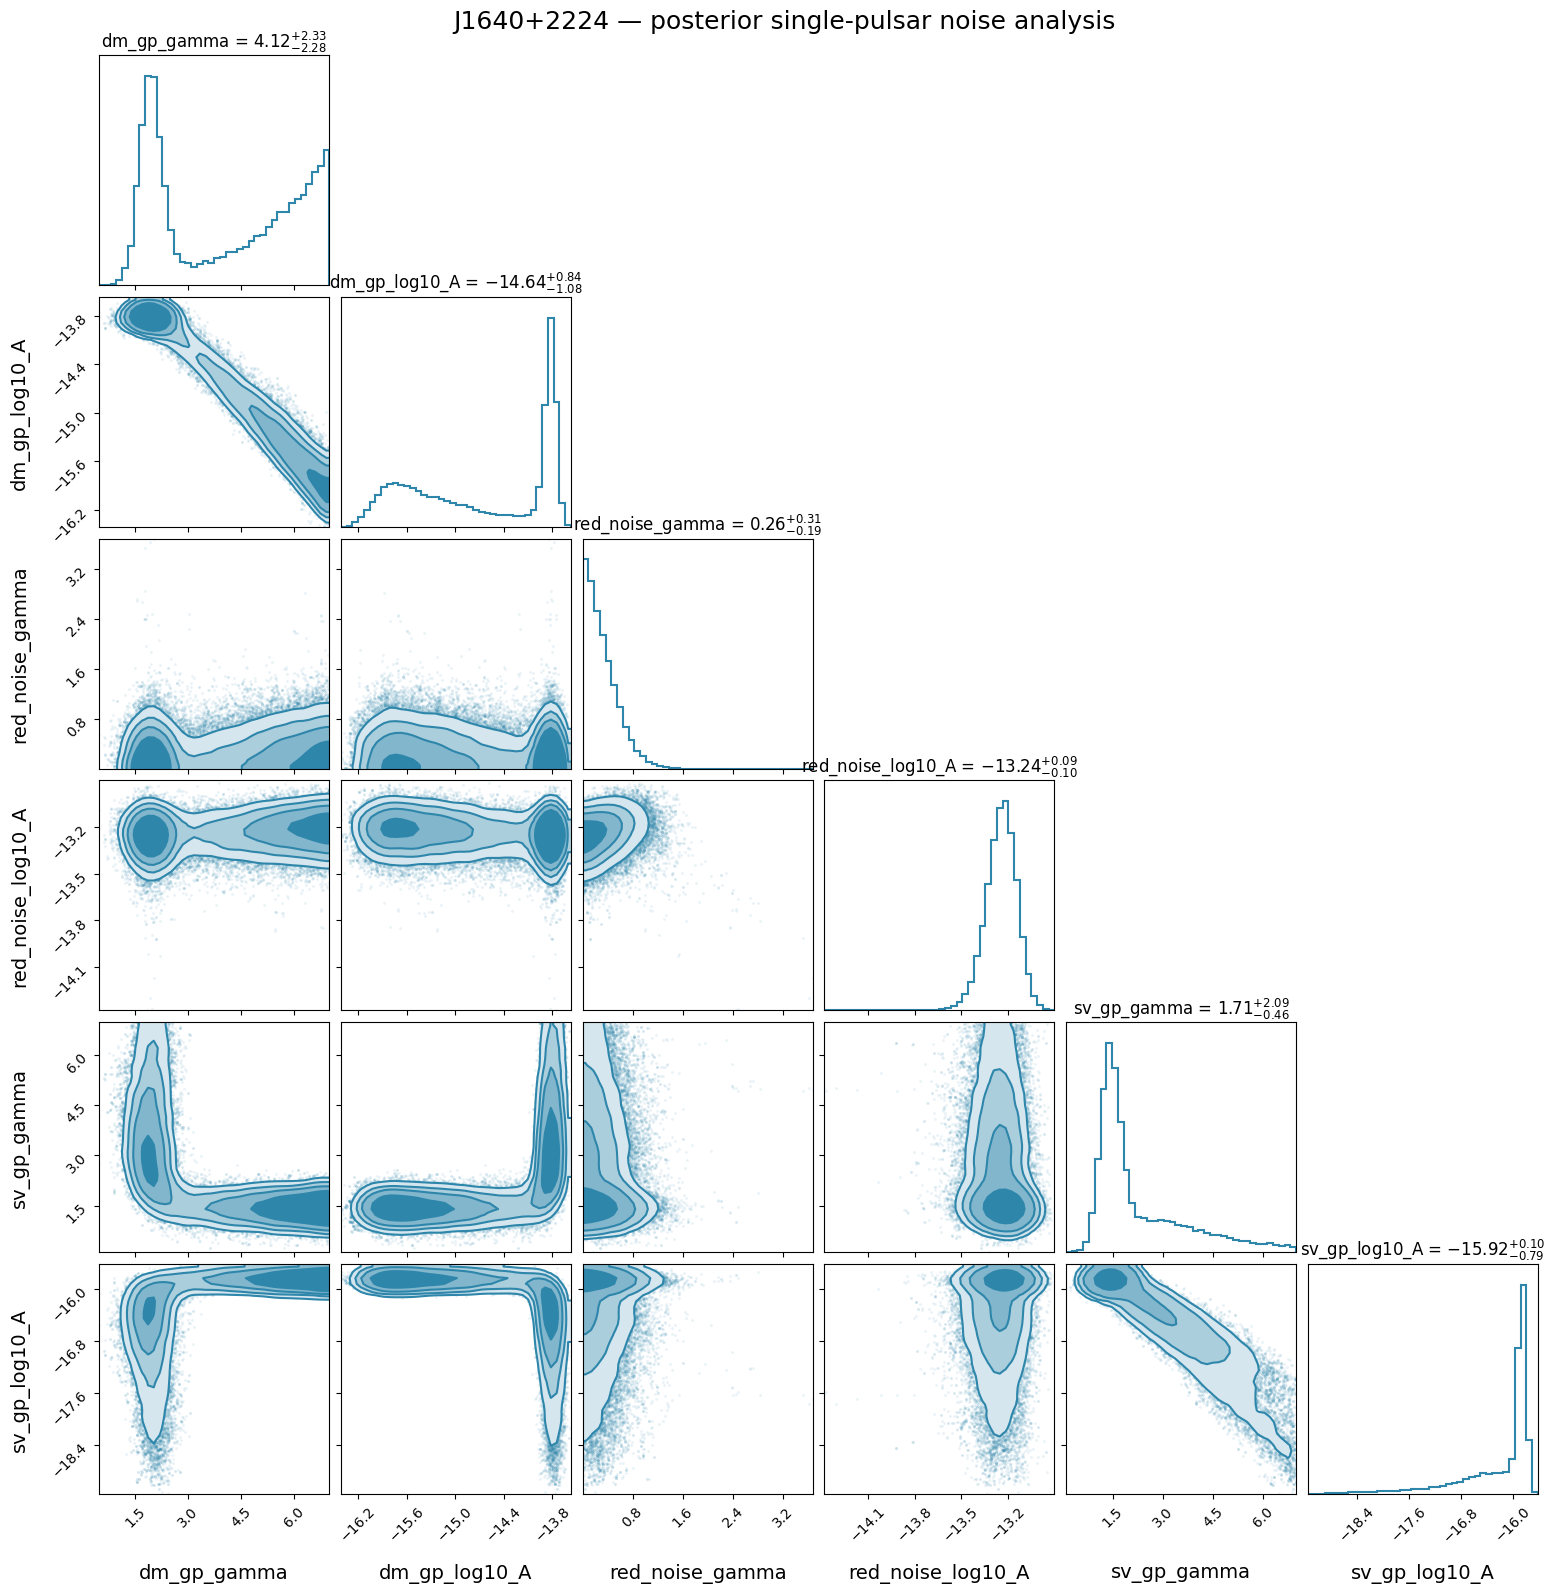

In [80]:
import corner

# Etichette pulite: tolgo "J1640+2224_" da ogni nome
clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

fig = corner.corner(
    chain[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 12},
    color='#2E86AB',
    hist_kwargs={'color': '#2E86AB', 'linewidth': 1.5 , "density": True},
    plot_datapoints=True,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    smooth1d=None,
    bins=40,
    
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — posterior single-pulsar noise analysis',
             fontsize=18, y=1.00)

fig.savefig('corner_J1640_pretty.png', dpi=150, bbox_inches='tight')

In [81]:
# --- Costruzione di chain_ref con corrispondenza dedotta dai nomi (idempotente) ---

# nomi degli ultimi 6 parametri Enterprise, nell'ordine della chain
ent_names = [str(p) for p in pars[-6:]]   # cn_4.0_gamma, cn_4.0_log10_A, dm_gamma, ...

# corrispondenza nomi Enterprise -> Discovery
def ent_to_disc(name):
    return (name.replace('cn_4.0', 'sv_gp')   # chromatic idx=4 -> scattering
                .replace('_dm_', '_dm_gp_'))  # dm              -> dm_gp
                                              # red_noise resta invariato

ent_mapped = [ent_to_disc(n) for n in ent_names]

# indice della colonna Enterprise corrispondente a ciascun parametro Discovery
col_order = [ent_mapped.index(p) for p in logL.params]
print('Riordino dedotto dai nomi:', col_order)   # atteso: [2, 3, 4, 5, 0, 1]

# garanzia formale: ogni colonna riordinata corrisponde davvero al parametro Discovery
assert [ent_mapped[i] for i in col_order] == list(logL.params), \
       "Mismatch tra parametri Enterprise e Discovery!"

# estrazione 6 colonne di rumore + riordino
chain_ref = chain_1[:, -10:-4][:, col_order]

# stesso burn-in del 25% applicato alla tua chain
chain_ref = chain_ref[len(chain_ref) // 4:]

print('shape chain_ref:', chain_ref.shape)

Riordino dedotto dai nomi: [2, 3, 4, 5, 0, 1]
shape chain_ref: (225001, 6)


In [82]:
Niter_enterprise = 3e6
n_righe_salvate = len(chain_1)          # prima del burn-in, la chain intera
thin_dedotto = Niter_enterprise / n_righe_salvate
print('thin Enterprise dedotto ≈', thin_dedotto)

thin Enterprise dedotto ≈ 9.999966666777777


In [144]:
#print('chain_ref.shape:', chain_ref.shape)

#tau_ref = np.array([
#    emcee.autocorr.integrated_time(chain_ref[:, i], quiet=True)[0]
 #   for i in range(chain_ref.shape[1])
#])
#print('tau Enterprise (6 valori):', tau_ref)
#print('Effective length (Enterprise) =', int(len(chain_ref) / tau_ref.max()))

In [83]:
tau_ref = emcee.autocorr.integrated_time(chain_ref, has_walkers=False, quiet=True)
print('tau Enterprise (6 valori):', tau_ref)

tau Enterprise (6 valori): [1491.91771966 1502.75863516  145.38867935  191.04874089  947.81249961
  896.93269499]


In [84]:
print('Effective length (Enterprise) =', int(len(chain_ref) / tau_ref.max()))

Effective length (Enterprise) = 149


In [85]:
tau_ref = emcee.autocorr.integrated_time(chain_ref, quiet=True)
print('tau Enterprise:', tau_ref)
print('Effective length (Enterprise) =', len(chain_ref[::int(tau_ref[0])]))

tau Enterprise: [831.58114342]
Effective length (Enterprise) = 271


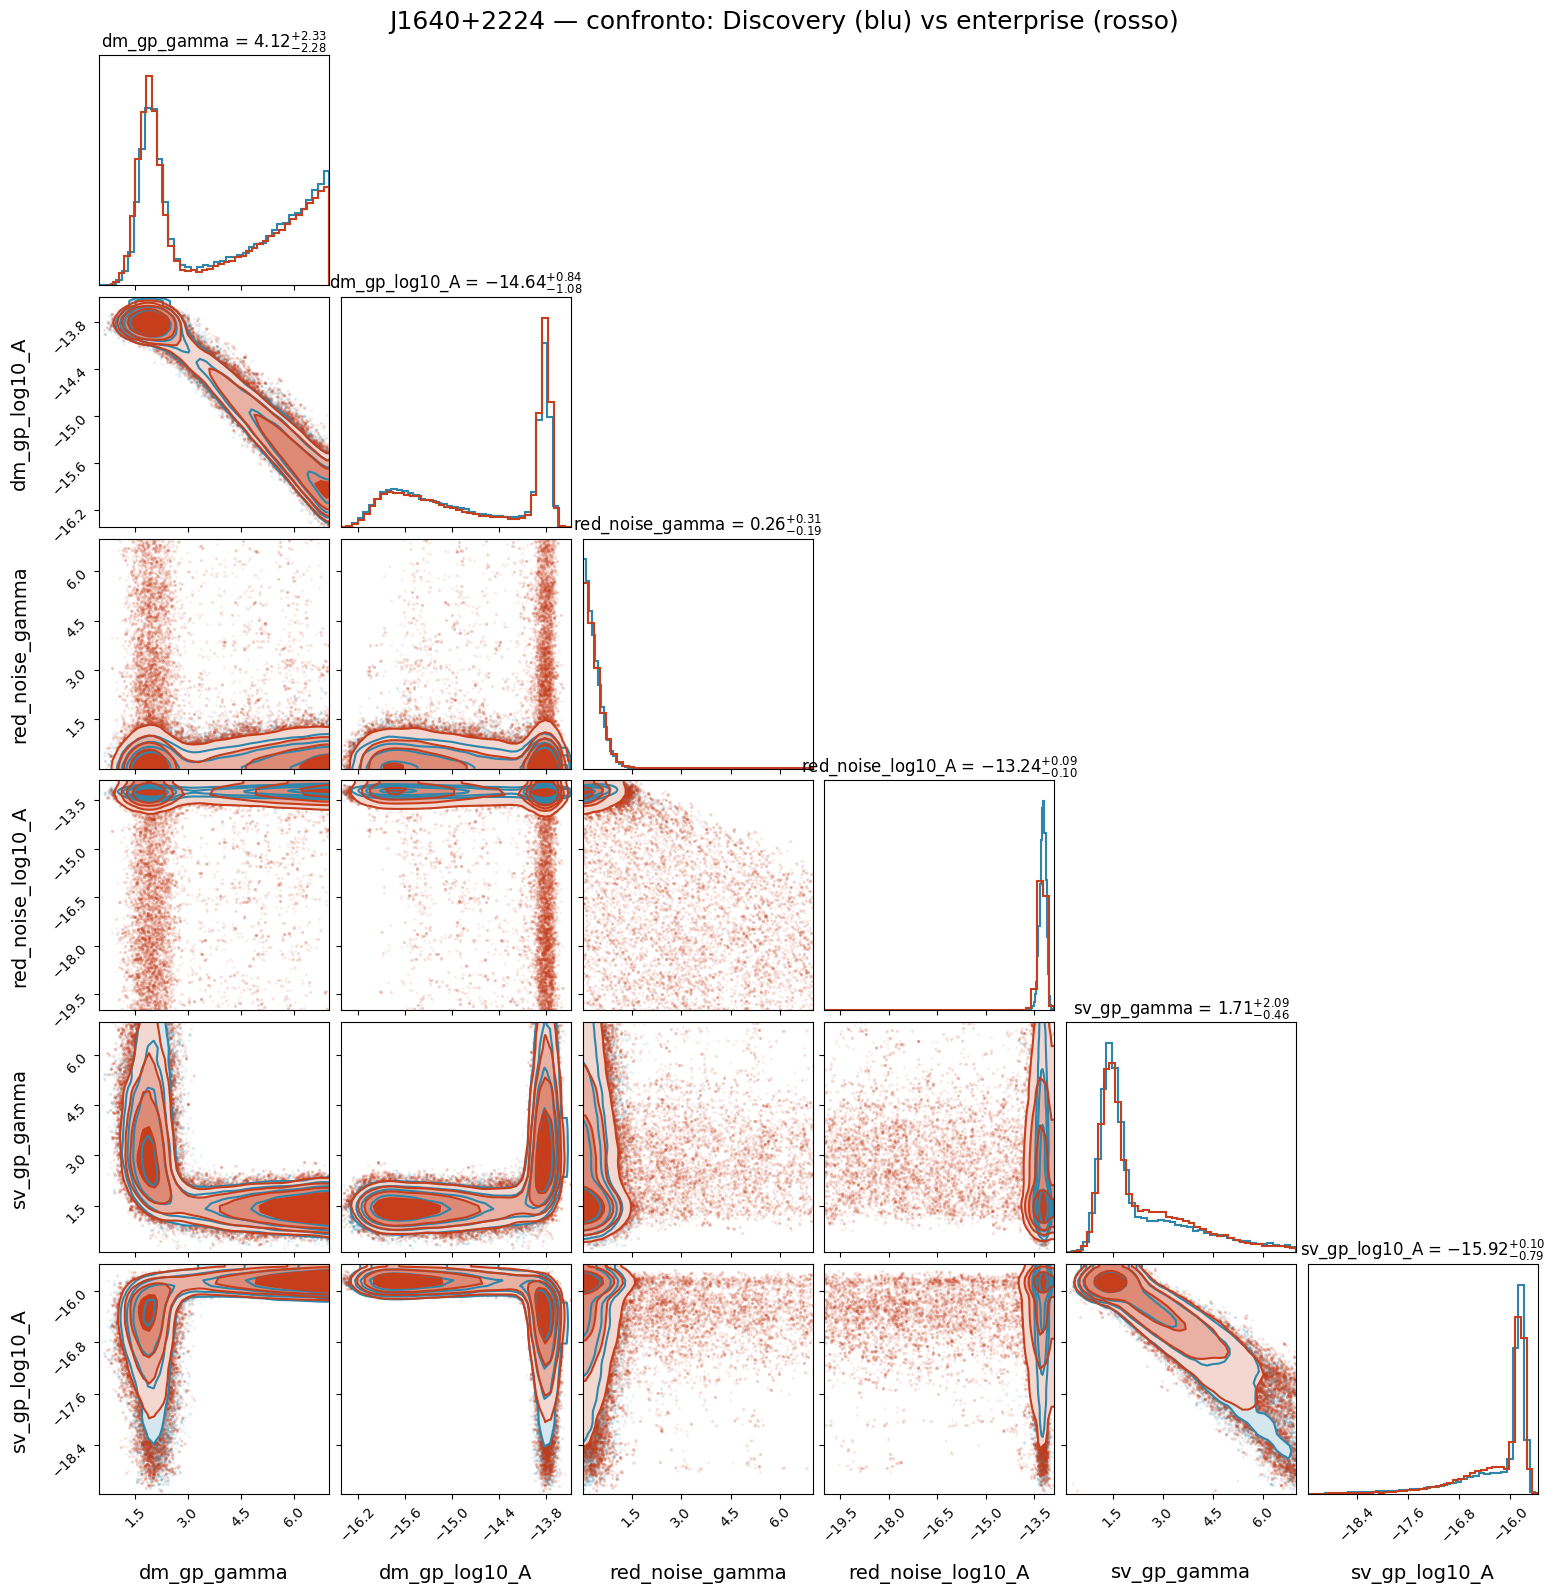

In [86]:
import corner

# Etichette pulite (senza il prefisso del pulsar)
clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# Primo corner: la TUA chain in blu
fig = corner.corner(
    chain[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 12},
    color='#2E86AB',
    hist_kwargs={'color': '#2E86AB', 'linewidth': 1.5 , "density": True},
    plot_datapoints=True,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    smooth1d=None,
    bins=40,
    
)

# Secondo corner: la chain di RIFERIMENTO in rosso, sovrapposta
corner.corner(
    chain_ref,
    labels=clean_labels,
    show_titles=False,            # non serve mostrare i titoli due volte
    color='#C73E1D',              # rosso
    hist_kwargs={'color': '#C73E1D', 'linewidth': 1.5 , "density": True },
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    smooth1d=None,
    bins=40,
    fig=fig,
    scale_hist=False,
);

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto: Discovery (blu) vs enterprise (rosso)',
             fontsize=18, y=1.00)

fig.savefig('corner_confronto.png', dpi=150, bbox_inches='tight')

In [87]:
import corner
print(corner.__version__)

2.2.3


In [88]:
# --- chain Enterprise NUOVA (10 colonne: 6 rossi + 4 diagnostiche) ---
chain_1_new = np.loadtxt('./spna_J1640/chain_1.txt')
print('shape grezza:', chain_1_new.shape)        # atteso (100001, 10)

chain_ref_new = chain_1_new[:, :-4]              # toglie le 4 diagnostiche -> 6 parametri rossi
chain_ref_new = chain_ref_new[len(chain_ref_new)//4:]   # burn-in 25%
print('shape chain_ref_new:', chain_ref_new.shape)      # atteso ~ (75000, 6)

shape grezza: (100001, 10)
shape chain_ref_new: (75001, 6)


In [89]:
tau_ref_new = emcee.autocorr.integrated_time(chain_ref_new, has_walkers=False, quiet=True)
tau_ref_new

array([48.18457771, 47.37201964,  6.84928255,  5.65389931, 41.59160512,
       38.38882179])

In [90]:
print('Effective length (Enterprise NUOVA) = ', len(chain_ref_new[::int(tau_ref_new.max())]))

Effective length (Enterprise NUOVA) =  1563


In [91]:
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# range comune: per ogni parametro, il min e max che contiene ENTRAMBE le catene
both = np.vstack([chain[:], chain_ref_new])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

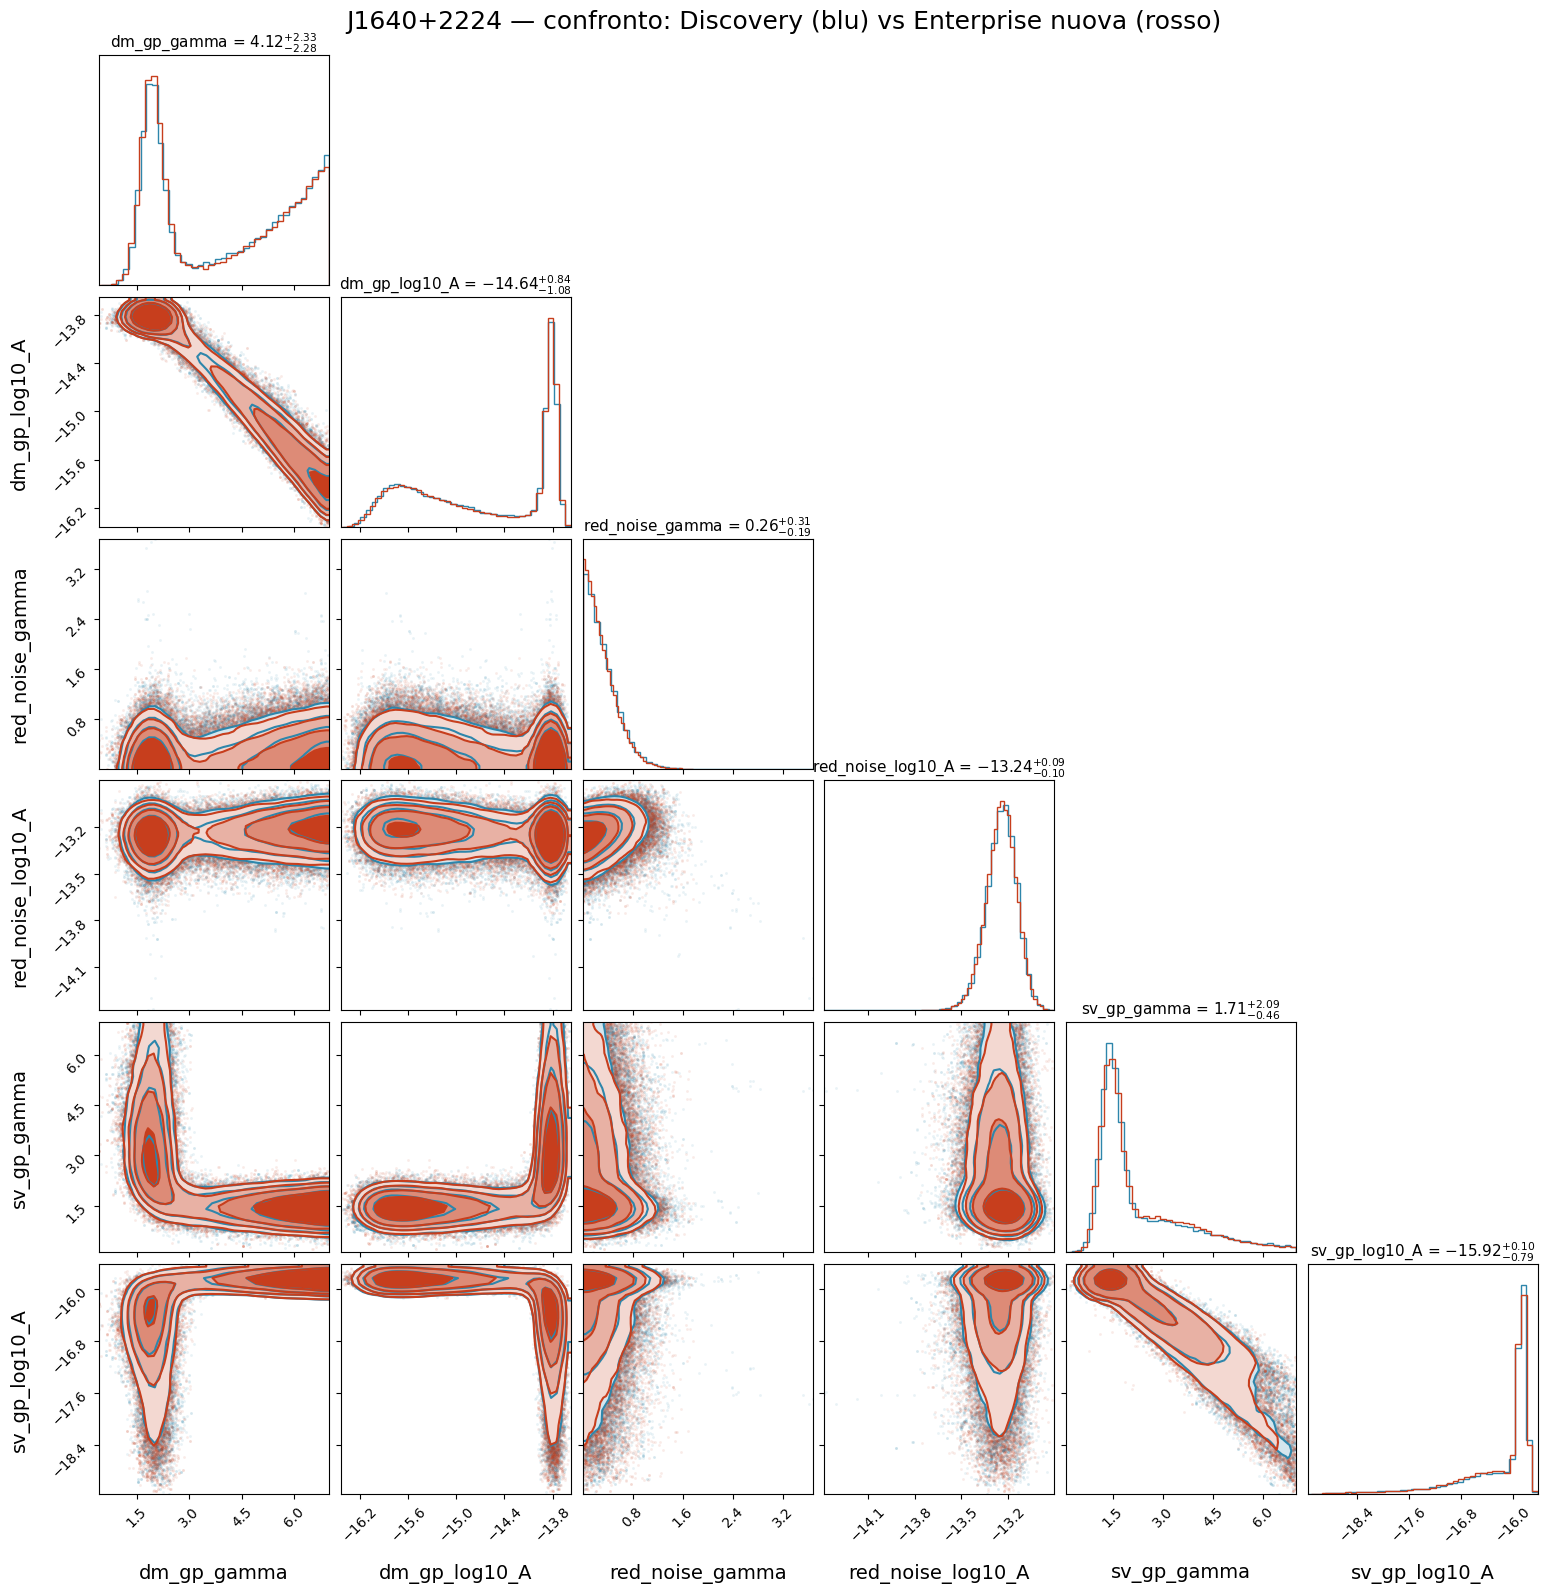

In [92]:
import corner

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# Discovery (la tua chain) in blu
fig = corner.corner(
    chain[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    smooth1d=None,
    bins=40,
    #range=common_range,
    hist_kwargs={"density": True}
)

# Enterprise NUOVA in rosso, sovrapposta
corner.corner(
    chain_ref_new,
    labels=clean_labels,
    show_titles=False,
    color='#C73E1D',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    smooth1d=None,
    bins=40,
    fig=fig,
    #range=common_range,
    hist_kwargs={"density": True}
);

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto: Discovery (blu) vs Enterprise nuova (rosso)',
             fontsize=18, y=1.00)

fig.savefig('corner_confronto_NEW.png', dpi=150, bbox_inches='tight')

In [104]:
path_dr2new = './dati/DR2new+_feathers/'
s_dsfiles_dr2new = np.sort(os.listdir(path_dr2new))
psr_dr2new = [ds.pulsar.Pulsar.read_feather(path_dr2new + f'{psrfile}') for psrfile in s_dsfiles_dr2new][9]

print('nome      :', psr_dr2new.name)
print('N_TOA     :', len(psr_dr2new.toas))
print('baseline  :', (psr_dr2new.toas.max() - psr_dr2new.toas.min()) / (86400 * 365.25), 'yr')
print('shape M   :', psr_dr2new.Mmat.shape)

nome      : J1640+2224
N_TOA     : 1546
baseline  : 10.217833858118416 yr
shape M   : (1546, 31)


In [106]:
# guarda cosa contiene davvero il noisedict di DR2new+
nd = psr_dr2new.noisedict
nome = psr_dr2new.name

# tutte le chiavi che contengono 'components'
comp_keys = [k for k in nd.keys() if 'components' in k.lower()]
print('chiavi con "components":')
for k in comp_keys:
    print(f'  {k} = {nd[k]}')

print()
# verifica le tre chiavi specifiche che servono al modello
for suff in ['_red_components', '_dm_components', '_chrom_components']:
    chiave = nome + suff
    print(f'{chiave}: {"PRESENTE = " + str(nd[chiave]) if chiave in nd else "MANCANTE"}')

chiavi con "components":
  J1640+2224_red_components = None
  J1640+2224_dm_components = 47
  J1640+2224_chrom_components = None

J1640+2224_red_components: PRESENTE = None
J1640+2224_dm_components: PRESENTE = 47
J1640+2224_chrom_components: PRESENTE = None


In [116]:
nd = psr_dr2new.noisedict
nome = psr_dr2new.name

# stampa TUTTE le chiavi del noisedict per questa pulsar
print('=== tutte le chiavi del noisedict DR2new+ ===')
for k in sorted(nd.keys()):
    print(f'  {k} = {nd[k]}')

=== tutte le chiavi del noisedict DR2new+ ===
  J1640+2224_EFF.P200.1380_efac = 1.6740103438387088
  J1640+2224_EFF.P200.1380_log10_tnequad = -8.119469937696858
  J1640+2224_EFF.P217.1380_efac = 1.0356321999126166
  J1640+2224_EFF.P217.1380_log10_tnequad = -8.361131309787513
  J1640+2224_EFF.S110.2487_efac = 1.344823590532148
  J1640+2224_EFF.S110.2487_log10_tnequad = -8.33652279211746
  J1640+2224_JBO.ROACH.1520_efac = 1.0900889895596009
  J1640+2224_JBO.ROACH.1520_log10_tnequad = -6.89888899120869
  J1640+2224_LEAP.1396_efac = 1.0755152580227818
  J1640+2224_LEAP.1396_log10_tnequad = -7.3394633596342995
  J1640+2224_NRT.NUPPI.1484_efac = 0.9349544896349673
  J1640+2224_NRT.NUPPI.1484_log10_tnequad = -7.946053186812969
  J1640+2224_chrom_components = None
  J1640+2224_dm_components = 47
  J1640+2224_dm_gp_gamma = 0.15539331668584155
  J1640+2224_dm_gp_log10_A = -13.18158534171036
  J1640+2224_red_components = None


In [117]:
print('=== confronto chiavi "components" DR2low vs DR2new+ ===')
for suff in ['_red_components', '_dm_components', '_chrom_components']:
    k = psr.name + suff
    kn = psr_dr2new.name + suff
    print(f'{suff}:  DR2low = {psr.noisedict.get(k)}   |   DR2new+ = {psr_dr2new.noisedict.get(kn)}')

=== confronto chiavi "components" DR2low vs DR2new+ ===
_red_components:  DR2low = 54   |   DR2new+ = None
_dm_components:  DR2low = 40   |   DR2new+ = 47
_chrom_components:  DR2low = 40   |   DR2new+ = None


In [137]:
# numero di componenti di riferimento (da DR2low, perche in DR2new+ erano None)
assert psr.name == psr_dr2new.name, f"Pulsar diverse! {psr.name} vs {psr_dr2new.name}"
n_red   = psr.noisedict[psr.name + '_red_components']
n_dm    = psr.noisedict[psr.name + '_dm_components']
n_chrom = psr.noisedict[psr.name + '_chrom_components']
print(f'componenti usate (da DR2low): red={n_red}, dm={n_dm}, chrom={n_chrom}')

model_dr2new = [psr_dr2new.residuals]
model_dr2new += [ds.makegp_timing(psr_dr2new, svd=True)]
model_dr2new += [ds.makenoise_measurement(psr_dr2new, psr_dr2new.noisedict, tnequad=True, ecorr=True)]
model_dr2new.append(ds.makegp_fourier(psr_dr2new, ds.powerlaw, n_red,
                                       T=ds.getspan(psr_dr2new), name='red_noise'))
model_dr2new.append(ds.makegp_fourier(psr_dr2new, ds.powerlaw, n_dm,
                                       T=ds.getspan(psr_dr2new), name='dm_gp',
                                       fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_dr2new.append(ds.makegp_fourier(psr_dr2new, ds.powerlaw, n_chrom,
                                       T=ds.getspan(psr_dr2new), name='sv_gp',
                                       fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))
logL_dr2new = ds.PulsarLikelihood(model_dr2new).logL
logL_dr2new.params

componenti usate (da DR2low): red=54, dm=40, chrom=40


['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [124]:
def params_dict_from_array_dr2new(x):
    x = np.asarray(x)
    return dict(zip(logL_dr2new.params, x))

priors_dr2new = build_priors(logL_dr2new.params, my_priordict)

def log_prior_dr2new(x):
    params = params_dict_from_array_dr2new(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_dr2new:
            logp += priors_dr2new[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_dr2new():
    return np.array([priors_dr2new[name].rvs() for name in logL_dr2new.params])

x0_dr2new = prior_draw_dr2new()
x0_dr2new

array([  0.04933308, -16.41305659,   0.30852631, -14.47127679,
         4.05068386, -18.55459183])

In [125]:
@jax.jit
def _jit_logL_dr2new(params_array):
    return logL_dr2new(dict(zip(logL_dr2new.params, params_array)))

def log_likelihood_dr2new(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_dr2new(jnp.array(x))))

_jit_logL_dr2new(x0_dr2new)

Array(16822.89870216, dtype=float64)

In [128]:
sampler_dr2new = ptmcmc(
    ndim=len(logL_dr2new.params),
    logl=log_likelihood_dr2new,
    logp=log_prior_dr2new,
    cov=np.eye(len(logL_dr2new.params)) * 0.001,
    outDir='./test_DR2newplus_6par/',     # cartella nuova
    resume=True
)

In [129]:
print("\nStarting sampling DR2new+ (6 parametri)...")
sampler_dr2new.sample(x0_dr2new, Niter=1000000, thin=10)


Starting sampling DR2new+ (6 parametri)...
Finished 1.00 percent (1.00 percent of new work) in 16.054379 s Acceptance rate = 0.3248Adding DE jump with weight 20
Finished 100.00 percent (100.00 percent of new work) in 2429.227778 s Acceptance rate = 0.109895
Run Complete


In [130]:
chain_dr2new = np.loadtxt('./test_DR2newplus_6par/chain_1.txt')[:, :-4]
chain_dr2new = chain_dr2new[len(chain_dr2new) // 4:]
chain_dr2new.shape    # atteso (~75000, 6)

(75001, 6)

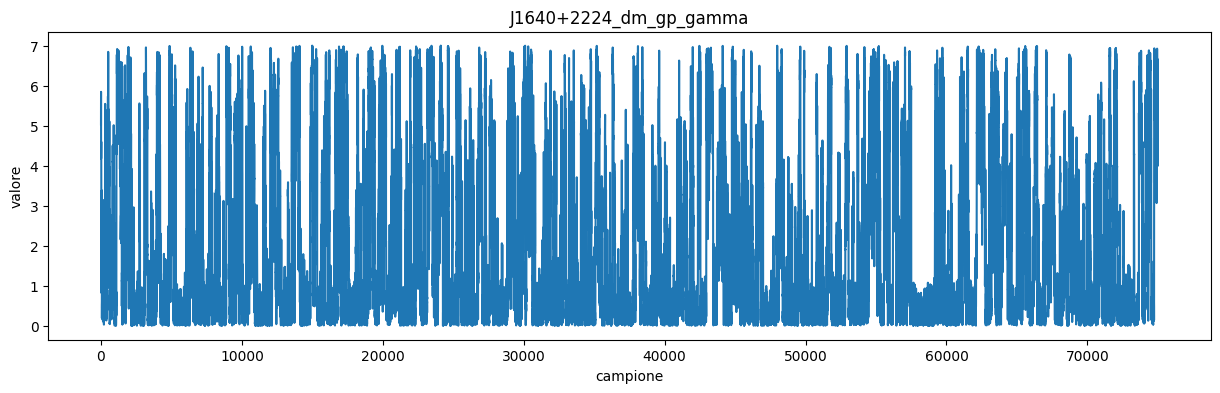

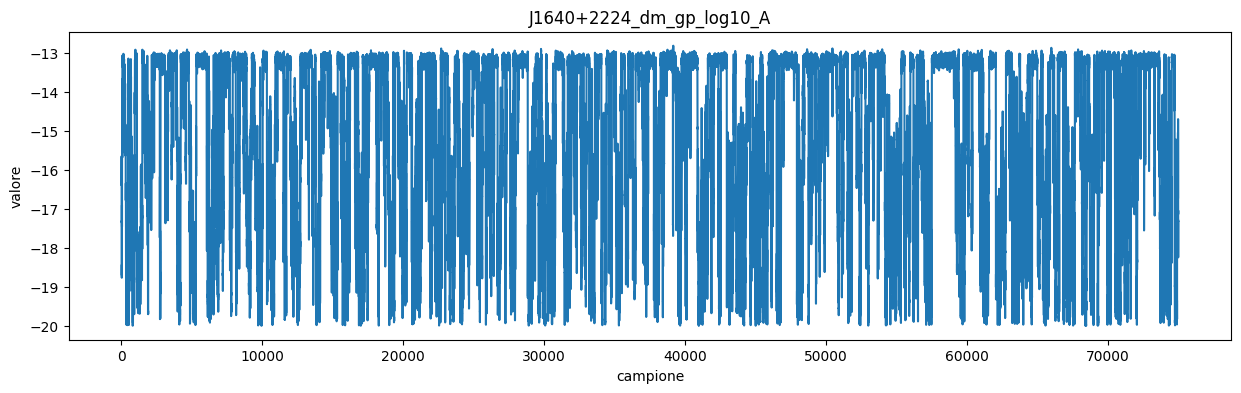

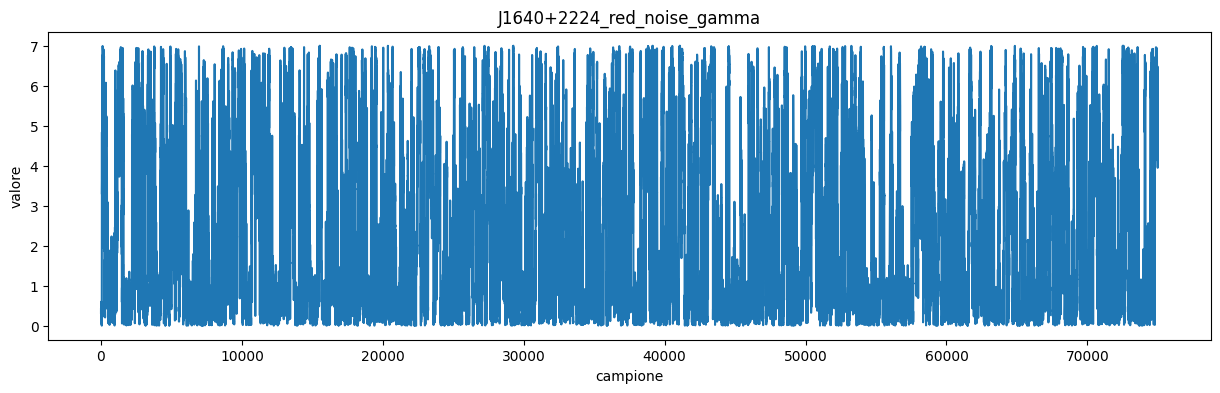

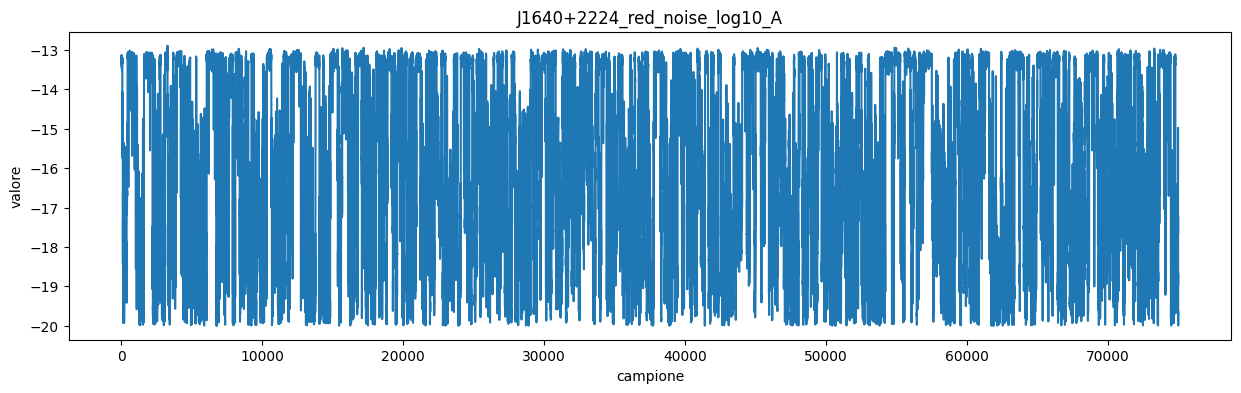

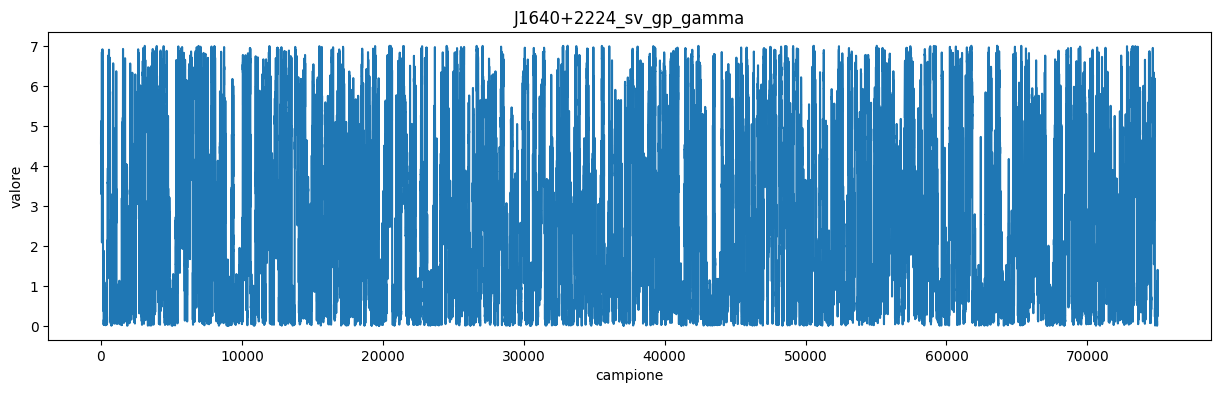

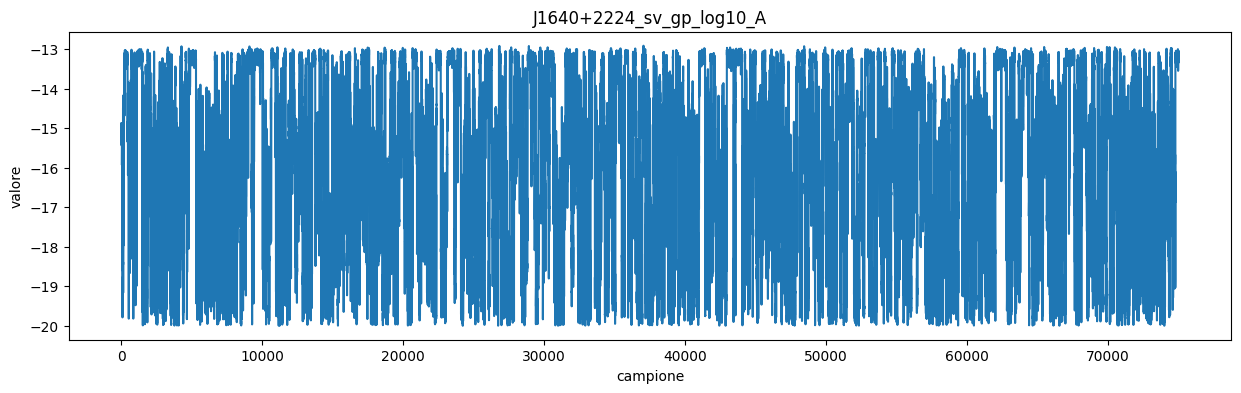

In [131]:
for i, ch in enumerate(chain_dr2new.T):
    plt.figure(figsize=(15, 4))
    plt.plot(ch)
    plt.title(logL_dr2new.params[i])
    plt.xlabel('campione')
    plt.ylabel('valore')
    plt.show()

In [132]:
tau_dr2new = emcee.autocorr.integrated_time(chain_dr2new, has_walkers=False, quiet=True)

print('--- DR2new+ ---')
for nome, t in zip(logL_dr2new.params, tau_dr2new):
    print(f'{nome}: tau = {t:.1f}  ->  eff. length = {len(chain_dr2new)/t:.0f}')

print(f'\ntau.max() = {tau_dr2new.max():.1f}')
print(f'Effective length (su tau.max) = {int(len(chain_dr2new)/tau_dr2new.max())}')

--- DR2new+ ---
J1640+2224_dm_gp_gamma: tau = 119.8  ->  eff. length = 626
J1640+2224_dm_gp_log10_A: tau = 134.9  ->  eff. length = 556
J1640+2224_red_noise_gamma: tau = 104.3  ->  eff. length = 719
J1640+2224_red_noise_log10_A: tau = 144.9  ->  eff. length = 518
J1640+2224_sv_gp_gamma: tau = 93.1  ->  eff. length = 806
J1640+2224_sv_gp_log10_A: tau = 130.0  ->  eff. length = 577

tau.max() = 144.9
Effective length (su tau.max) = 517


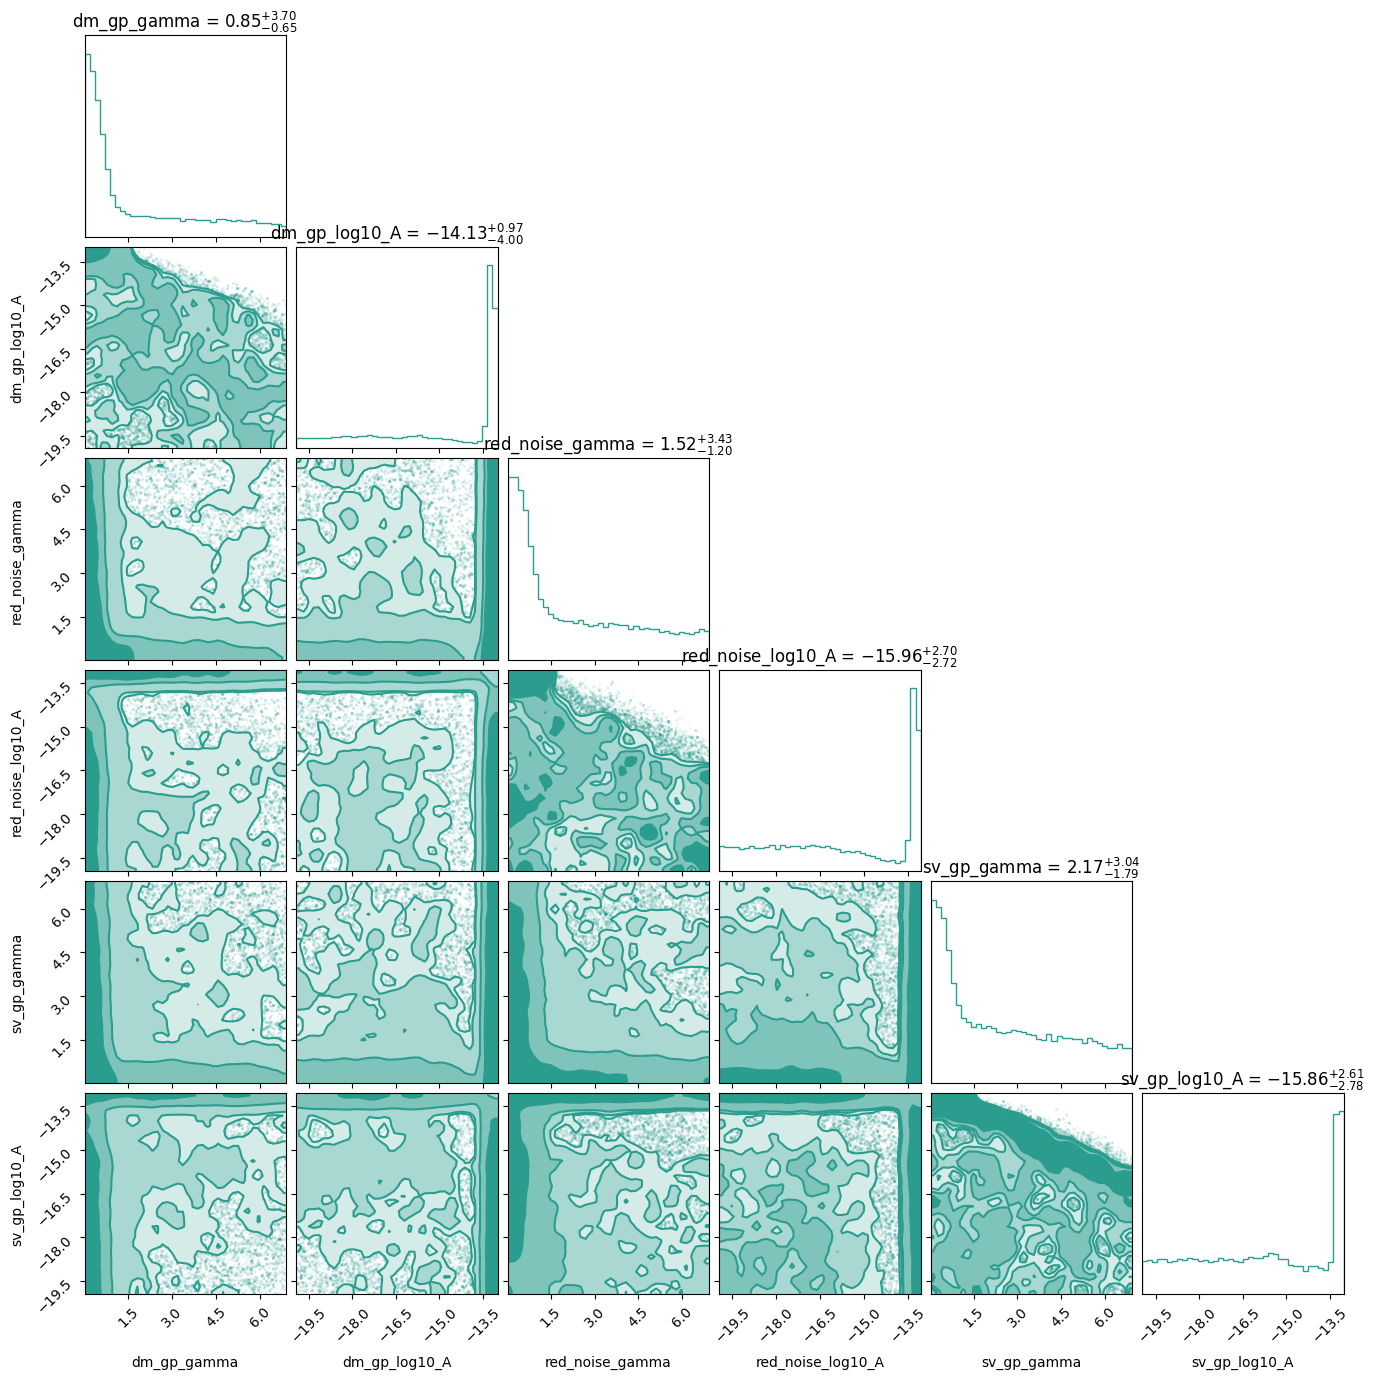

In [140]:
import corner

clean_labels = [name.replace('J1640+2224_', '') for name in logL_dr2new.params]

fig = corner.corner(
    chain_dr2new[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    color='#2A9D8F',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    bins=40,
    range=[0.99]*chain_dr2new.shape[1],   # taglia l'1% di code estreme per parametro
)
fig.set_size_inches(14, 14)
fig.savefig('corner_DR2new_solo.png', dpi=150, bbox_inches='tight')

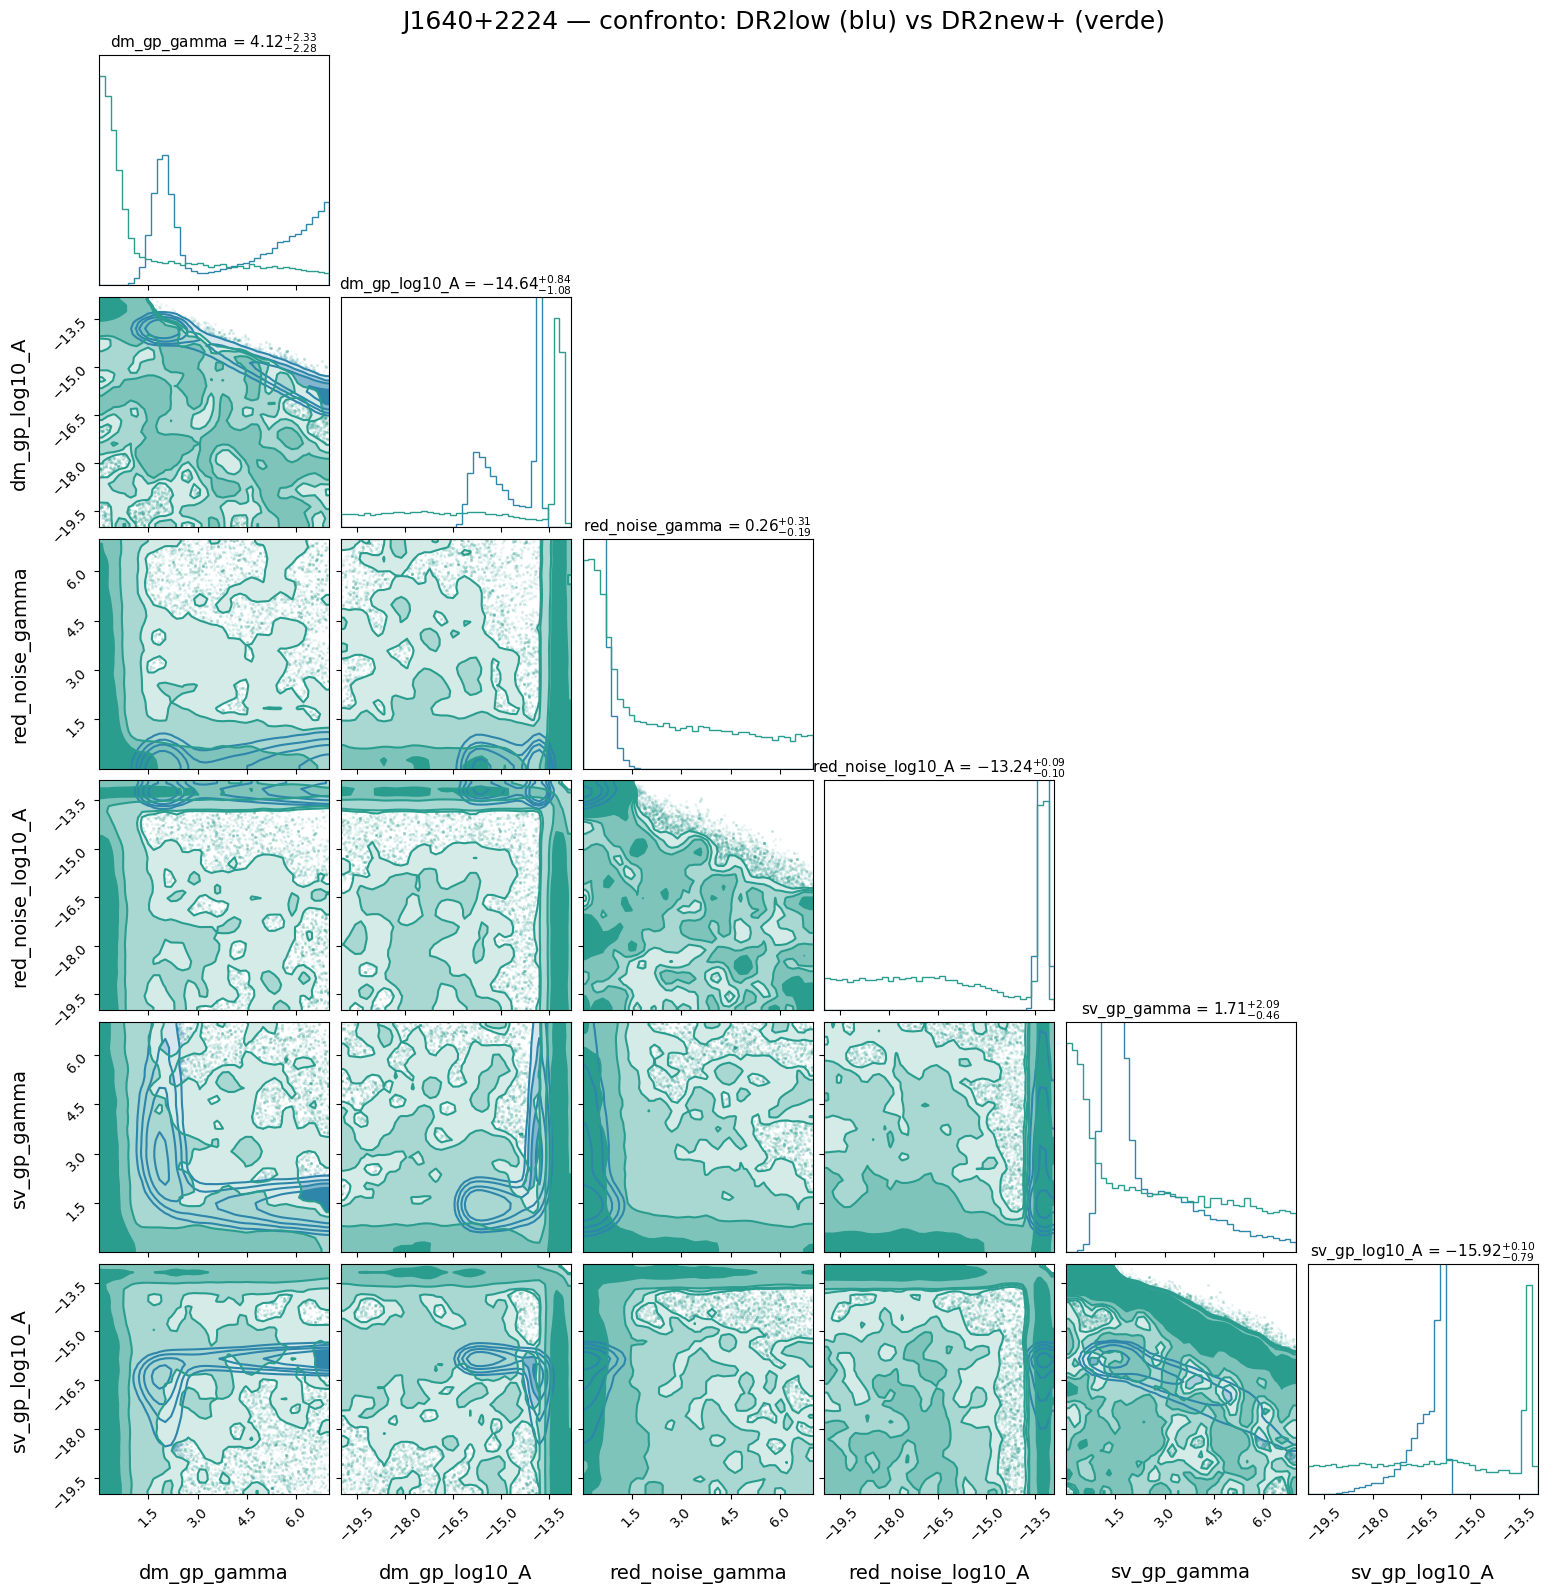

In [133]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL_dr2new.params]

# range comune che contiene entrambe le catene
both = np.vstack([chain[:], chain_dr2new[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# DR2low in blu
fig = corner.corner(
    chain[:],
    labels=clean_labels,
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    bins=40,
    range=common_range,
)

# DR2new+ in verde, sovrapposto
corner.corner(
    chain_dr2new[:],
    labels=clean_labels,
    show_titles=False,
    color='#2A9D8F',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    bins=40,
    range=common_range,
    fig=fig,
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto: DR2low (blu) vs DR2new+ (verde)', fontsize=18, y=1.00)
fig.savefig('corner_DR2low_vs_DR2new.png', dpi=150, bbox_inches='tight')

In [134]:
import numpy as np

print('=== forma delle catene ===')
print('chain (DR2low)   :', chain.shape)
print('chain_dr2new     :', chain_dr2new.shape)
print()

print('=== DR2new+: range e mediana per parametro ===')
for i, nome in enumerate(logL_dr2new.params):
    col = chain_dr2new[:, i]
    print(f'{nome.replace("J1640+2224_",""):20s} '
          f'min={col.min():8.3f}  med={np.median(col):8.3f}  max={col.max():8.3f}')
print()

print('=== controllo prior (i valori devono stare DENTRO questi limiti) ===')
print('gamma: [0, 7]   |   log10_A: [-20, -11]')
print()

# quanti valori unici? se sono pochissimi, la catena non si e' mossa (sampler bloccato)
print('=== valori unici per colonna (se ~1, la catena e bloccata) ===')
for i, nome in enumerate(logL_dr2new.params):
    print(f'{nome.replace("J1640+2224_",""):20s} valori unici = {len(np.unique(chain_dr2new[:, i]))}')

=== forma delle catene ===
chain (DR2low)   : (75001, 6)
chain_dr2new     : (75001, 6)

=== DR2new+: range e mediana per parametro ===
dm_gp_gamma          min=   0.000  med=   0.848  max=   6.997
dm_gp_log10_A        min= -20.000  med= -14.129  max= -12.816
red_noise_gamma      min=   0.000  med=   1.518  max=   6.999
red_noise_log10_A    min= -20.000  med= -15.957  max= -12.894
sv_gp_gamma          min=   0.000  med=   2.172  max=   6.999
sv_gp_log10_A        min= -20.000  med= -15.863  max= -12.915

=== controllo prior (i valori devono stare DENTRO questi limiti) ===
gamma: [0, 7]   |   log10_A: [-20, -11]

=== valori unici per colonna (se ~1, la catena e bloccata) ===
dm_gp_gamma          valori unici = 47114
dm_gp_log10_A        valori unici = 47114
red_noise_gamma      valori unici = 47114
red_noise_log10_A    valori unici = 47114
sv_gp_gamma          valori unici = 47114
sv_gp_log10_A        valori unici = 47114


In [93]:
# carica la pulsar simulata (residui sintetici generati dal codice Simulations)
sim_psr = ds.pulsar.Pulsar.read_feather('sim_data_noise/J1640+2224')

print('nome     :', sim_psr.name)
print('N_TOA    :', len(sim_psr.toas))
print('shape M  :', sim_psr.Mmat.shape)

nome     : J1640+2224
N_TOA    : 6777
shape M  : (6777, 39)


In [94]:
# stesso modello dell'analisi reale, ma sui dati simulati
model_sim = [sim_psr.residuals]
model_sim += [ds.makegp_timing(sim_psr, svd=True)]
model_sim += [ds.makenoise_measurement(sim_psr, sim_psr.noisedict, tnequad=True, ecorr=True)]
model_sim.append(ds.makegp_fourier(sim_psr, ds.powerlaw, sim_psr.noisedict[sim_psr.name + '_red_components'],
                                   T=ds.getspan(sim_psr), name='red_noise'))
model_sim.append(ds.makegp_fourier(sim_psr, ds.powerlaw, sim_psr.noisedict[sim_psr.name + '_dm_components'],
                                   T=ds.getspan(sim_psr), name='dm_gp',
                                   fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim.append(ds.makegp_fourier(sim_psr, ds.powerlaw, sim_psr.noisedict[sim_psr.name + '_chrom_components'],
                                   T=ds.getspan(sim_psr), name='sv_gp',
                                   fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))

logL_sim = ds.PulsarLikelihood(model_sim).logL
logL_sim.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [95]:
def params_dict_from_array_sim(x):
    x = np.asarray(x)
    return dict(zip(logL_sim.params, x))

# riusa lo stesso my_priordict e build_priors gia definiti nel notebook
priors_sim = build_priors(logL_sim.params, my_priordict)

def log_prior_sim(x):
    params = params_dict_from_array_sim(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim:
            logp += priors_sim[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim():
    return np.array([priors_sim[name].rvs() for name in logL_sim.params])

@jax.jit
def _jit_logL_sim(params_array):
    return logL_sim(dict(zip(logL_sim.params, params_array)))

def log_likelihood_sim(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim(jnp.array(x))))

x0_sim = prior_draw_sim()
print('logL iniziale =', log_likelihood_sim(x0_sim))

logL iniziale = 67710.0858200954


In [96]:
sampler_sim = ptmcmc(
    ndim=len(logL_sim.params),
    logl=log_likelihood_sim,
    logp=log_prior_sim,
    cov=np.eye(len(logL_sim.params)) * 0.001,
    outDir='./test_sim/',
    resume=True
)

In [97]:
print("Starting sampling (dati simulati)...")
sampler_sim.sample(x0_sim, Niter=1000000, thin=10)

Starting sampling (dati simulati)...
Resuming run from chain file ./test_sim//chain_1.txt
Resuming with 100001 samples from file representing 1000001 original samples
Adding DE jump with weight 20

Run Complete


In [98]:
chain_sim = np.loadtxt('./test_sim/chain_1.txt')[:, :-4]
chain_sim = chain_sim[len(chain_sim)//4:]
print('shape chain_sim:', chain_sim.shape)

shape chain_sim: (75001, 6)


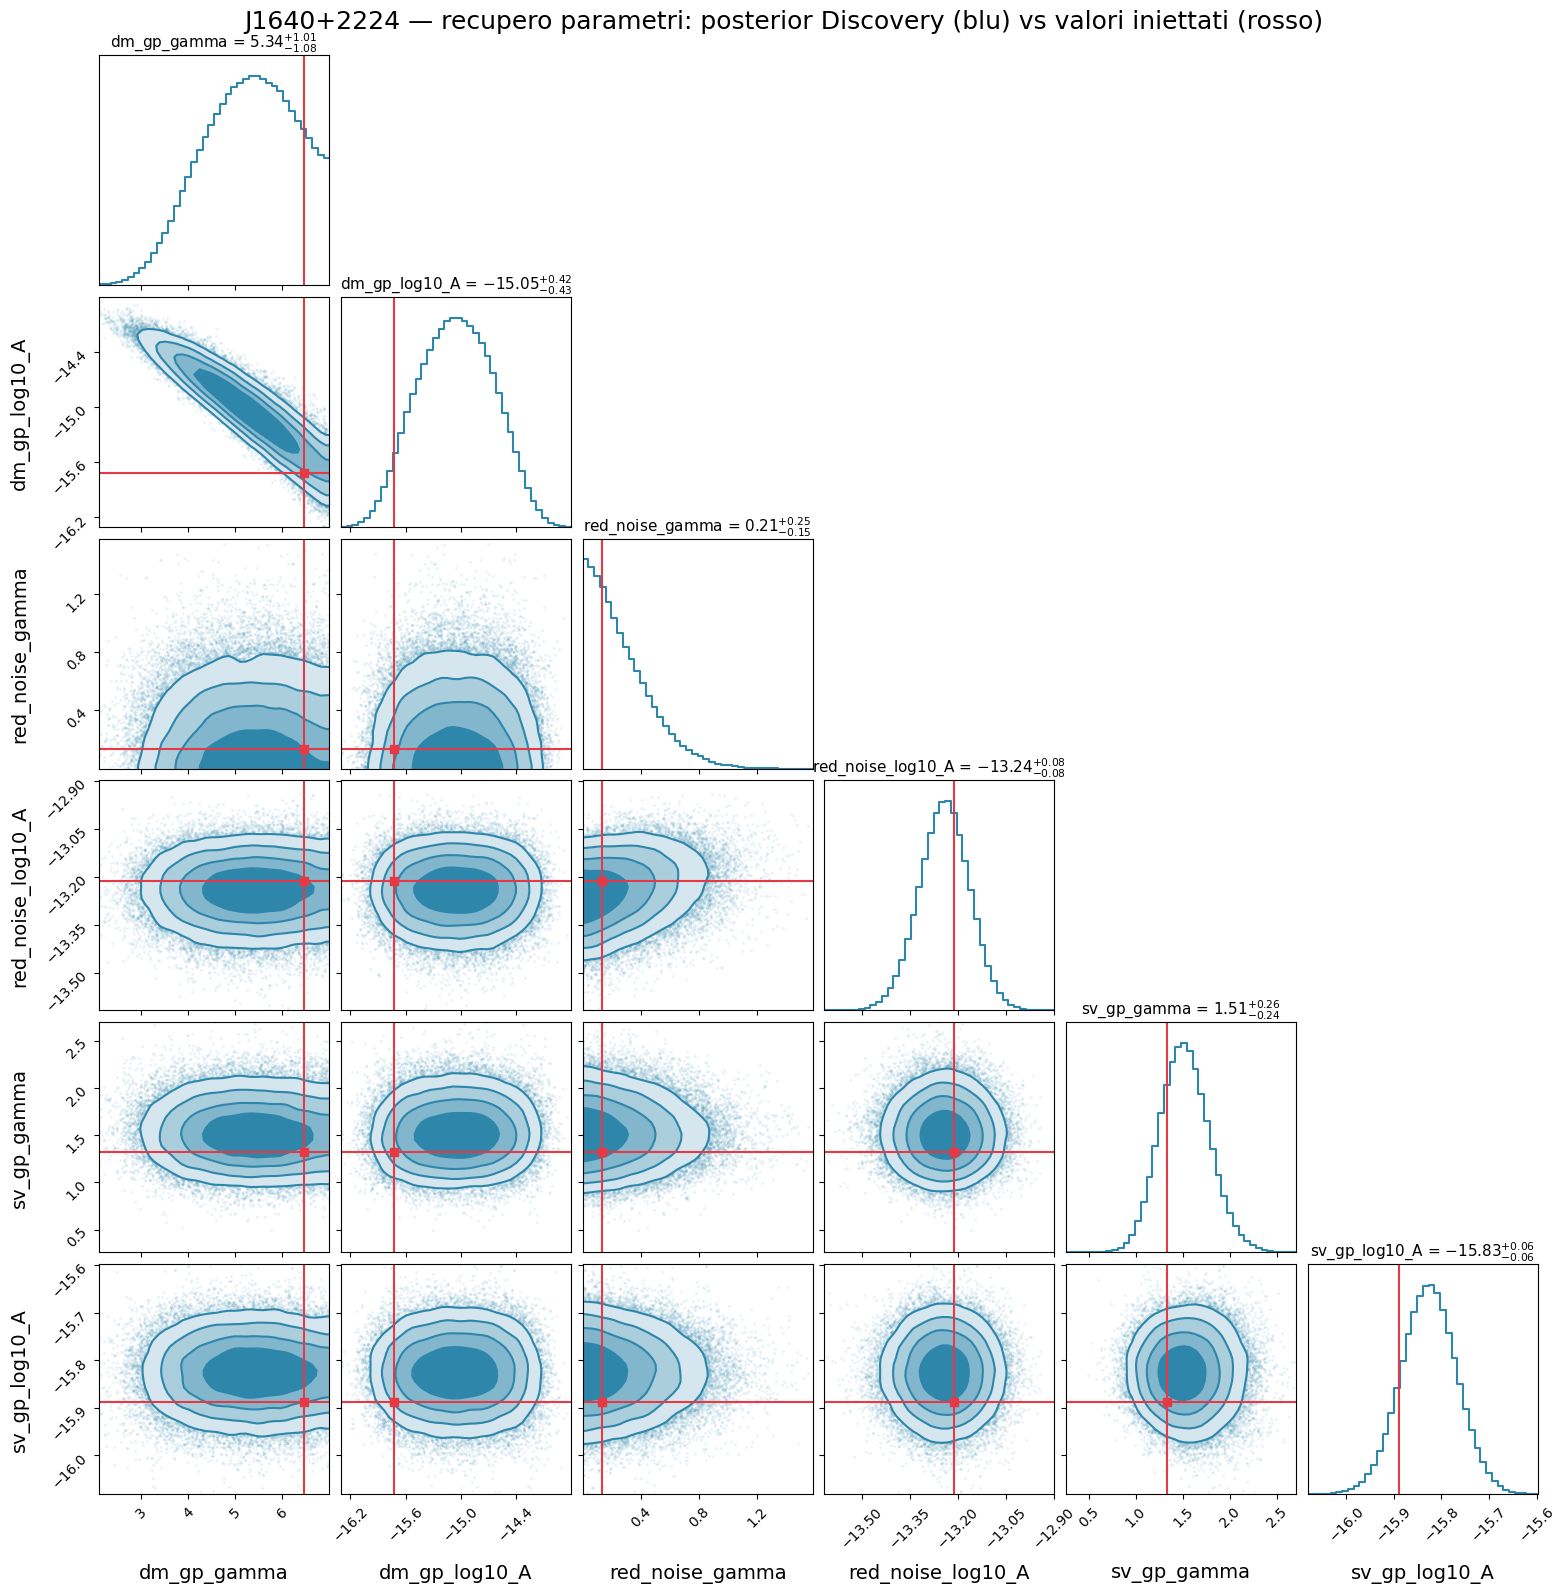

In [99]:
import corner

truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim.params]

fig = corner.corner(
    chain_sim[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#E63946',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1, smooth1d=1.0,
    bins=40,
)
fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — recupero parametri: posterior Discovery (blu) vs valori iniettati (rosso)',
             fontsize=18, y=1.00)
fig.savefig('corner_recovery_sim.png', dpi=150, bbox_inches='tight')

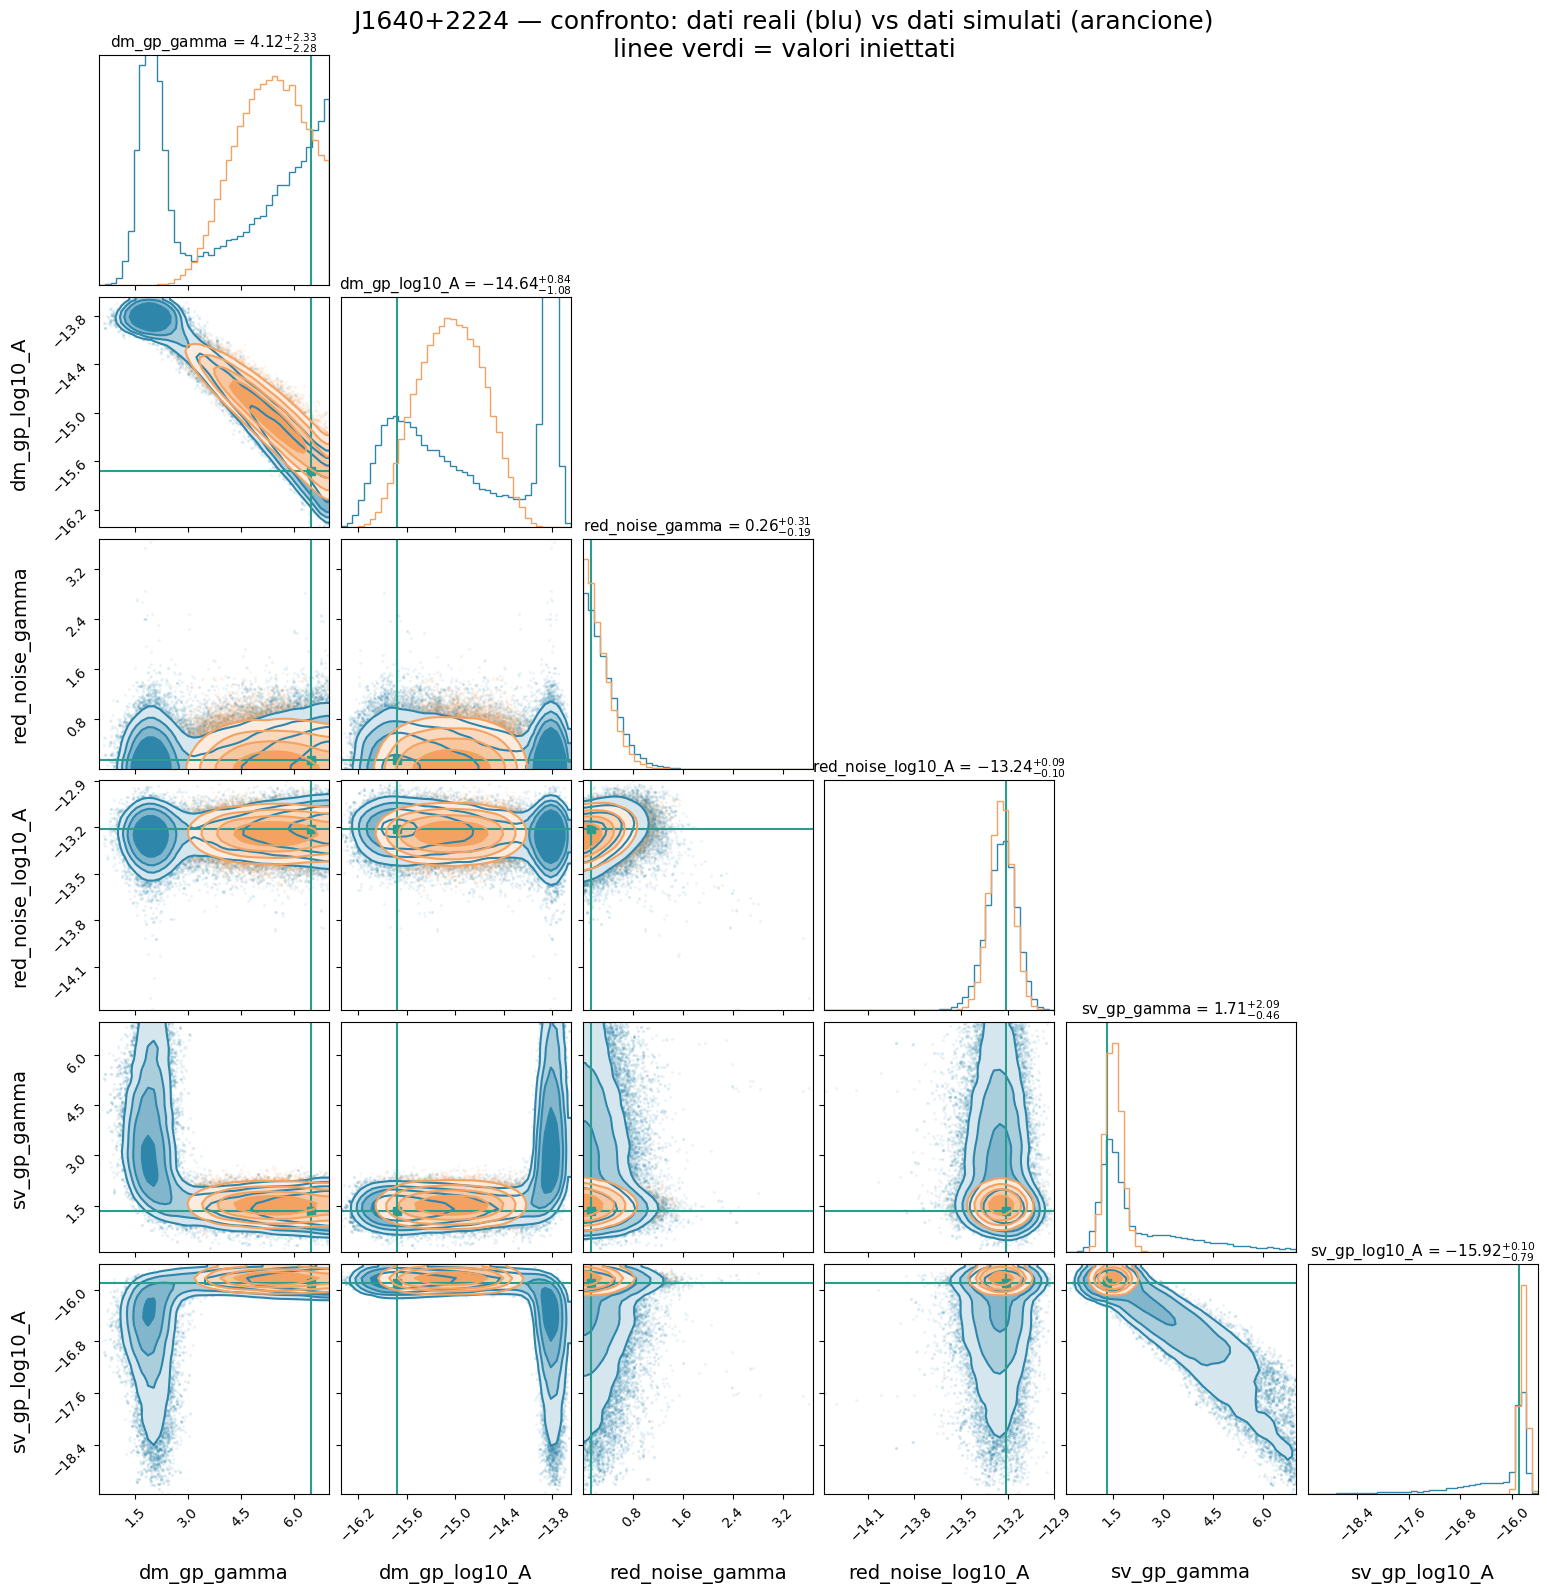

In [101]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# valori veri iniettati, nell'ordine dei parametri
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain[:], chain_sim[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# Dati REALI in blu
fig = corner.corner(
    chain[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#2A9D8F',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

# Dati SIMULATI in rosso, sovrapposti
corner.corner(
    chain_sim[:],
    labels=clean_labels,
    show_titles=False,
    color='#F4A261',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto: dati reali (blu) vs dati simulati (arancione)\nlinee verdi = valori iniettati',
             fontsize=18, y=1.00)
fig.savefig('corner_reali_vs_simulati.png', dpi=150, bbox_inches='tight')